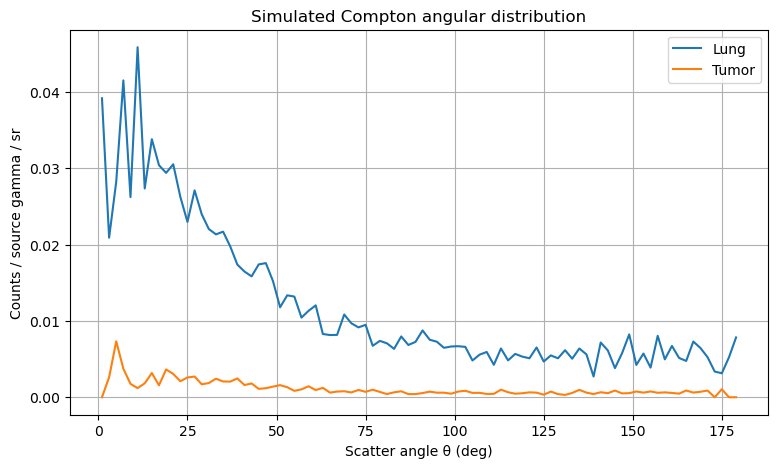

In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

root_file = "tumor.root"
tree_name = "t"

# Change these to your volume IDs
#lung_vlm  = 2
#tumor_vlm = 3

# Lu-177 gamma energy
E0 = 113.0   # keV

# If your tree uses process code:
# 2013 may be Compton in your setup, but confirm by printing pro values
compton_code = 2013

# Incident gamma direction from source
# example: source at y=20 cm shooting toward -y
kin = np.array([0.0, -1.0, 0.0])

f = ROOT.TFile.Open(root_file)
t = f.Get(tree_name)

#angles_lung = []
angles_tumor = []

for event in t:
    n = len(event.vlm)

    for i in range(n):

        # Select only gamma Compton interactions
        if event.pdg[i] != 22:
            continue

        if event.pro[i] != compton_code:
            continue

        if event.vlm[i] not in [lung_vlm, tumor_vlm]:
            continue

        # Need outgoing direction after scattering
        # Replace px,py,pz by your branch names if different
        p = np.array([event.px[i], event.py[i], event.pz[i]])
        norm = np.linalg.norm(p)

        if norm == 0:
            continue

        kout = p / norm

        cos_theta = np.dot(kin, kout)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)

        theta = np.degrees(np.arccos(cos_theta))

        if event.vlm[i] == lung_vlm:
            angles_lung.append(theta)

        if event.vlm[i] == tumor_vlm:
            angles_tumor.append(theta)

# Histogram in angle
bins = np.linspace(0, 180, 91)
centers = 0.5 * (bins[:-1] + bins[1:])

lung_counts, _ = np.histogram(angles_lung, bins=bins)
tumor_counts, _ = np.histogram(angles_tumor, bins=bins)

# Convert dtheta bins to solid angle bins
theta_rad1 = np.radians(bins[:-1])
theta_rad2 = np.radians(bins[1:])
dOmega = 2 * np.pi * (np.cos(theta_rad1) - np.cos(theta_rad2))

# Normalize
N_events = t.GetEntries()

lung_rate = lung_counts / (N_events * dOmega)
tumor_rate = tumor_counts / (N_events * dOmega)

plt.figure(figsize=(9, 5))
plt.plot(centers, lung_rate, label="Lung")
plt.plot(centers, tumor_rate, label="Tumor")

plt.xlabel("Scatter angle θ (deg)")
plt.ylabel("Counts / source gamma / sr")
plt.title("Simulated Compton angular distribution")
plt.legend()
plt.grid(True)
plt.show()